#CS project
# Name: Seyed Ali Vakilzadeh
# STID: 401102789


# Smart-grid simulators: Core Data Structures

We begin by defining two lightweight data models that represent the life cycle of energy demand in our system:

- **Arrival**: an external demand event, generated when a consumer requests energy.  
  Includes optional fields for priority and deadline to support different scheduling policies.

- **Request**: an internal queue item created from an `Arrival`.  
  Stores service-related timestamps (start, finish) so we can measure waiting times, system times, and completion.


In [1]:
from dataclasses import dataclass
from collections import deque
from typing import List, Dict, Callable, Optional, Tuple
import math, random, statistics
import numpy as np

@dataclass
class Arrival:
    """External demand event from a consumer at a specific minute."""
    consumer_id: int
    demand: float
    priority: int = 1                 # lower value = higher priority
    deadline: Optional[int] = None    # absolute minute (for EDF-like policies)

@dataclass
class Request:
    """Internal queue item created from an Arrival, with service lifecycle timestamps."""
    rid: int
    consumer_id: int
    demand: float
    arrival_time: int
    priority: int = 1
    deadline: Optional[int] = None
    start_service_time: Optional[int] = None
    finish_time: Optional[int] = None


# Modeling Rush-Hour Demand & Arrivals

We now define helper functions that capture **time-varying energy demand** patterns:

- **Gaussian bump helpers**: create smooth peaks at specified hours (e.g. 7–9 and 18–22) to model rush hours.
- **χ(t) (xi)**: per-user arrival intensity function.
- **λ₁(t), λ₂(t)**: parameters from the paper — represent service rates / supply processes, made time-dependent (rush-hour bumps and daylight sinusoid).
- **Demand multiplier**: scales job sizes (kWh demand) in sync with rush-hour peaks.
- **Arrival provider**: generates per-minute *Arrivals* using a Poisson process with time-varying χ(t), plus demand, priority, and deadline.

This layer allows us to plug in realistic temporal patterns (rush-hour surges, day


In [2]:
# ---------- rush-hour Gaussian bump helpers ----------

def make_gaussian_bump_fn(
    peak_hours: List[Tuple[int,int]] = [(7,9),(18,22)],
    width_min: float = 90.0,
    base: float = 0.005,
    peak_scale: float = 10.0
) -> Callable[[int], float]:
    """Return χ(t)-like function: base + Gaussian bumps at peak hours."""
    centers = [int(0.5*(h1+h2)*60) for (h1,h2) in peak_hours]
    def f(t: int) -> float:
        m = t % 1440
        bump = sum(math.exp(-((m-c)**2)/(2*width_min**2)) for c in centers)
        return max(0.0, base*(1.0 + peak_scale*bump))
    return f

def make_xi_rate_fn(peak_hours, width, base=0.005, peak_scale=10.0):
    """Wrapper: χ(t) arrival rate."""
    return make_gaussian_bump_fn(peak_hours, width, base, peak_scale)

def make_lambda1_fn(base_mu=2.0, peak_bump=0.0,
                    peak_hours=[(7,9),(18,22)], width_min=90.0):
    """λ₁(t): base_mu scaled by rush-hour bump (if peak_bump > 0)."""
    if peak_bump == 0.0:
        return lambda t: base_mu
    bump = make_gaussian_bump_fn(peak_hours, width_min, base=0.0, peak_scale=1.0)
    return lambda t: max(0.0, base_mu*(1.0 + peak_bump*bump(t)))

def make_lambda2_daylight_fn(peak_lambda=800.0, days=1):
    """λ₂(t): daylight sinusoid peaking at noon, zero at night."""
    minutes_per_day = 1440
    total_minutes = days*minutes_per_day
    def lam2(t: int) -> float:
        if t >= total_minutes: return 0.0
        h = (t % minutes_per_day)/60.0
        if 6 <= h <= 18:
            x = (h-6)/12.0
            return peak_lambda*0.5*(1 - math.cos(math.pi*x))
        return 0.0
    return lam2

# ---------- demand multiplier (rush-hour aligned) ----------

def make_multiplier_from_peaks(
    peak_hours: List[Tuple[int,int]] = [(7,9),(18,22)],
    multiplier_base: float = 1.0,
    multiplier_peak_scale: float = 1.0,
    peak_width_min: float = 90.0
) -> Callable[[int, int], float]:
    """Scale demand sizes (per job) with same bumps as arrivals."""
    centers = [int(0.5*(h1+h2)*60) for (h1,h2) in peak_hours]
    def mult(t: int, cid: int) -> float:
        m = t % 1440
        bump = sum(math.exp(-((m-c)**2)/(2*peak_width_min**2)) for c in centers)
        return max(0.0, multiplier_base*(1.0 + multiplier_peak_scale*bump))
    return mult

# ---------- Poisson arrivals with time-varying χ(t) ----------

def make_poisson_arrival_provider_timevarying(
    num_consumers: int,
    days: int,
    xi_rate_fn: Callable[[int], float],
    demand_sampler: Callable[[], float],
    priority_fn: Callable[[int,int], int] = lambda cid,t: 1,
    deadline_fn: Callable[[int,int], int] = lambda t,mod: t+240,
    rng_seed: Optional[int] = None
) -> Callable[[int], List[Arrival]]:
    """Generate arrivals per minute for each consumer with χ(t)-driven Poisson arrivals."""
    if rng_seed is not None:
        random.seed(rng_seed)
    minutes_total = days*1440
    def provider(t: int) -> List[Arrival]:
        if t >= minutes_total: return []
        p_user = 1.0 - math.exp(-xi_rate_fn(t))  # per-user arrival prob
        out: List[Arrival] = []
        mod = t % 1440
        for cid in range(num_consumers):
            if random.random() < p_user:
                out.append(Arrival(
                    consumer_id=cid,
                    demand=demand_sampler(),
                    priority=priority_fn(cid,t),
                    deadline=deadline_fn(t,mod),
                ))
        return out
    return provider


# Controller Gate, Outages, and Supply Sequences

This section prepares the control and supply side of the smart-grid model:

- **Controller Gate** (`λ₁`, *N*):  
  Models the admission control step from the paper — a Poisson server with rate `λ₁(t)` and `N` parallel processors.  
  Arrivals are first placed in a waiting pool, and at each minute a random number of them (∼Poisson(λ₁(t)·N)) are admitted.

- **Outages**:  
  Generate a boolean mask with one random outage window per day (uniformly selecting a start hour).  
  Utilities:
  - `make_daily_outage_mask`: builds the mask.  
  - `describe_outage_schedule`: pretty-prints per-day outage intervals in HH:MM.

- **Supply & workload materialization**:  
  - `materialize_safe_and_fossil_sequences`: simulates renewable (λ₂-based Poisson) and fossil supply sequences, zeroing them during outages.  
  - `materialize_raw_arrivals`: generates exogenous arrivals for each minute.  
  - `materialize_admissions`: applies the controller gate to those arrivals, producing admitted demand streams.


In [15]:
# ---------- controller gate (λ1, N) ----------

class ControllerGate:
    """Admission controller: admits arrivals at rate λ₁(t) with N parallel processors."""
    def __init__(self, lambda1_fn: Callable[[int], float], servers_N: int = 1, seed: Optional[int] = None):
        self.lambda1_fn = lambda1_fn
        self.N = servers_N
        self.waiting_pool: List[Arrival] = []
        self.rng = np.random.RandomState(seed)

    def push_waiting(self, arrivals: List[Arrival]):
        self.waiting_pool.extend(arrivals)

    def pop_admitted(self, t: int) -> List[Arrival]:
        mu = max(0.0, float(self.lambda1_fn(t))) * self.N
        S = int(self.rng.poisson(mu))
        if S <= 0 or not self.waiting_pool:
            return []
        S = min(S, len(self.waiting_pool))
        batch = self.waiting_pool[:S]
        del self.waiting_pool[:S]
        return batch


# ---------- outages ----------

def make_daily_outage_mask(days: int,
                           duration_min: int = 60,
                           seed: int | None = None,
                           minutes_per_day: int = 1440) -> list[bool]:
    """
    Single canonical outage helper used by all code paths.
    For each day, pick a uniform random start hour in {0..23}, then mark a continuous
    'duration_min' window as outage (True).
    """
    import random as _rand
    rng = _rand.Random(seed)
    T = days * minutes_per_day
    mask = [False] * T
    for d in range(days):
        start_hour = rng.randrange(0, 24)
        start = d*minutes_per_day + start_hour*60
        end = min(start + duration_min, (d+1)*minutes_per_day)
        for m in range(start, end):
            mask[m] = True
    return mask



def describe_outage_schedule(mask: list[bool]) -> str:
    """Return a per-day human-readable description of outage slots."""
    out = []
    T = len(mask); days = T // 1440
    for d in range(days):
        base = d*1440
        start = None
        for m in range(base, base+1440):
            if mask[m]:
                start = m; break
        if start is None:
            out.append(f"Day {d+1}: none"); continue
        end = start
        while end < base+1440 and mask[end]:
            end += 1
        h1, n1 = (start-base)//60, (start-base)%60
        h2, n2 = (end-base)//60, (end-base)%60
        out.append(f"Day {d+1}: {h1:02d}:{n1:02d}–{h2:02d}:{n2:02d}")
    return "\n".join(out)


# ---------- supply & workload materialization ----------

def materialize_safe_and_fossil_sequences(
    lambda2_fn: Callable[[int], float],
    fossil_fn: Callable[[int], float],
    total_minutes: int,
    outage_mask: Optional[List[bool]] = None,
    seed: Optional[int] = None
) -> Tuple[List[float], List[float]]:
    """Generate renewable and fossil supply sequences, applying outages if given."""
    rng = np.random.RandomState(seed)
    safe_seq = [float(rng.poisson(max(0.0, float(lambda2_fn(t))))) for t in range(total_minutes)]
    fossil_seq = [float(fossil_fn(t)) for t in range(total_minutes)]
    if outage_mask:
        for t in range(min(total_minutes, len(outage_mask))):
            if outage_mask[t]:
                safe_seq[t] = 0.0
                fossil_seq[t] = 0.0
    return safe_seq, fossil_seq

def materialize_raw_arrivals(provider: Callable[[int], List[Arrival]], total_minutes: int) -> List[List[Arrival]]:
    """Produce per-minute exogenous arrivals."""
    return [provider(t) for t in range(total_minutes)]

def materialize_admissions(
    raw_arrivals_by_min: List[List[Arrival]],
    lambda1_fn: Callable[[int], float],
    servers_N: int,
    seed: Optional[int] = None
) -> List[List[Arrival]]:
    """Apply the controller gate to raw arrivals, returning admitted arrivals per minute."""
    gate = ControllerGate(lambda1_fn=lambda1_fn, servers_N=servers_N, seed=seed)
    admitted: List[List[Arrival]] = []
    for t in range(len(raw_arrivals_by_min)):
        gate.push_waiting(raw_arrivals_by_min[t])
        admitted.append(gate.pop_admitted(t))
    return admitted


# Multi-Policy Smart-Grid Simulator

This simulator executes energy allocation under different **queuing policies**:

- **FIFO** (First-In First-Out): serves requests in arrival order.  
- **PRIORITY**: serves by smallest `priority` value, breaking ties by arrival time.  
- **WRR** (Weighted Round Robin): each consumer receives service quantum proportional to its weight.  
- **EDF** (Earliest Deadline First): serves requests by soonest deadline.

**Energy model**:
- Service order per request: `safe → battery → fossil`.  
- If the minute is marked as outage, both safe and fossil are zero, and the battery is frozen.  
- Battery charges only from unused safe energy.

**Collected metrics**:
- Request-level: average wait, 95th percentile wait, average system time.  
- System-level: queue length, cost (∝ L²), energy mix (safe/battery/fossil).  
- All metrics are printed in a structured summary at the end of each run.


In [14]:
# ---------- multi-policy simulator (FIFO/PRIORITY/WRR/EDF) ----------

class SmartGridSimMulti:
    """
    Policies: FIFO | PRIORITY | WRR | EDF
    Energy order: safe -> battery -> fossil.
    Outage minutes: safe=0, fossil=0, battery frozen.
    """
    def __init__(
        self,
        num_consumers: int,
        total_minutes: int,
        policy: str = "FIFO",
        battery_capacity: float = 1000.0,
        price_fn: Callable[[int], float] = lambda t: 1.0,
        safe_sequence: Optional[List[float]] = None,
        fossil_sequence: Optional[List[float]] = None,
        wrr_weights: Optional[Dict[int, float]] = None,
        wrr_base_quantum: float = 50.0,
        consumption_demand_multiplier: Callable[[int,int], float] = lambda t,cid: 1.0,
        outage_mask: Optional[List[bool]] = None,
    ):
        self.N = num_consumers
        self.T = total_minutes
        self.policy = policy.upper()
        assert self.policy in {"FIFO","PRIORITY","WRR","EDF"}

        self.price_fn = price_fn
        self.safe_seq = safe_sequence or [0.0]*total_minutes
        self.fossil_seq = fossil_sequence or [0.0]*total_minutes
        self.outage_mask = outage_mask or [False]*total_minutes

        self.batt_cap = float(battery_capacity)
        self.batt = 0.0

        self.time = 0
        self.next_rid = 0
        self.queues: Dict[int, deque] = {i: deque() for i in range(self.N)}

        # logs
        self.arrivals_log: List[Tuple[int,int,float,int,Optional[int]]] = []
        self.served: List[Request] = []
        self.leftover: List[Request] = []
        self.per_min_load: List[float] = []
        self.per_min_queue_len: List[int] = []
        self.per_min_energy_mix: List[Dict[str,float]] = []
        self.per_min_cost: List[float] = []

        # WRR parameters
        self.wrr_w = wrr_weights if wrr_weights is not None else {i: 1.0 for i in range(self.N)}
        self.wrr_base_quantum = float(wrr_base_quantum)
        self.multiplier_fn = consumption_demand_multiplier

    def run_with_frozen_admissions(self, admitted_by_minute: List[List[Arrival]]):
        """Run simulation using pre-admitted arrivals (after controller gate)."""
        while self.time < self.T:
            arrivals = admitted_by_minute[self.time] if self.time < len(admitted_by_minute) else []
            self.step(arrivals)
        for q in self.queues.values():
            self.leftover.extend(list(q))

    def step(self, arrivals: List[Arrival]):
        t = self.time
        # enqueue arrivals
        for a in arrivals:
            if 0 <= a.consumer_id < self.N:
                d = a.demand * self.multiplier_fn(t, a.consumer_id)
                self.arrivals_log.append((t, a.consumer_id, d, a.priority, a.deadline))
                self.queues[a.consumer_id].append(Request(self.next_rid, a.consumer_id, d, t, a.priority, a.deadline))
                self.next_rid += 1

        safe_avail = self.safe_seq[t] if t < len(self.safe_seq) else 0.0
        fossil_avail = self.fossil_seq[t] if t < len(self.fossil_seq) else 0.0
        is_outage = (t < len(self.outage_mask) and self.outage_mask[t])

        self.per_min_queue_len.append(sum(len(q) for q in self.queues.values()))
        used = {"safe":0.0, "battery":0.0, "fossil":0.0}

        def take_from(source: str, need: float) -> float:
            nonlocal safe_avail, fossil_avail
            if need <= 0: return 0.0
            if is_outage: return 0.0
            if source == "safe":
                x = min(safe_avail, need); safe_avail -= x; used["safe"] += x; return x
            if source == "battery":
                x = min(self.batt, need); self.batt -= x; used["battery"] += x; return x
            x = min(fossil_avail, need); fossil_avail -= x; used["fossil"] += x; return x

        def serve_req(req: Request) -> float:
            need = req.demand
            delivered = 0.0
            for src in ("safe","battery","fossil"):
                got = take_from(src, need - delivered)
                if got > 0 and req.start_service_time is None:
                    req.start_service_time = t
                delivered += got
                if delivered + 1e-9 >= need:
                    req.demand = 0.0; req.finish_time = t
                    return delivered
            req.demand -= delivered
            return delivered

        # policy-specific service
        if self.policy == "FIFO": self._serve_fifo(serve_req)
        elif self.policy == "PRIORITY": self._serve_priority(serve_req)
        elif self.policy == "WRR": self._serve_wrr(serve_req)
        elif self.policy == "EDF": self._serve_edf(serve_req)

        # charge battery with leftover safe
        if not is_outage and safe_avail > 0.0:
            charge = min(self.batt_cap - self.batt, safe_avail)
            self.batt += charge; safe_avail -= charge

        # logging
        L = used["safe"] + used["battery"] + used["fossil"]
        self.per_min_load.append(L)
        self.per_min_energy_mix.append(used)
        self.per_min_cost.append(self.price_fn(t) * (L**2))
        self.time += 1

    # --- service policies ---

    def _serve_fifo(self, serve_req):
        while True:
            progressed=False
            for cid,q in self.queues.items():
                if not q: continue
                r = q[0]
                delivered = serve_req(r)
                if r.demand <= 1e-9: self.served.append(r); q.popleft()
                if delivered>0: progressed=True
            if not progressed: break

    def _serve_priority(self, serve_req):
        while True:
            heads=[(r.priority if r.priority is not None else 1, r.arrival_time, cid)
                   for cid,q in self.queues.items() if q for r in [q[0]]]
            if not heads: break
            heads.sort(key=lambda x:(x[0],x[1]))
            progressed=False
            for _,_,cid in heads:
                if not self.queues[cid]: continue
                r=self.queues[cid][0]
                delivered=serve_req(r)
                if r.demand <= 1e-9: self.served.append(r); self.queues[cid].popleft()
                if delivered>0: progressed=True
            if not progressed: break

    def _serve_wrr(self, serve_req):
        weights = {cid: max(0.0, float(self.wrr_w.get(cid,1.0))) for cid in range(self.N)}
        total_w = sum(weights.values()) or 1.0
        quanta = {cid: self.wrr_base_quantum*(weights[cid]/total_w) for cid in range(self.N)}
        while True:
            progressed=False
            if not any(len(q)>0 for q in self.queues.values()): break
            for cid in range(self.N):
                q = self.queues[cid]
                if not q or quanta[cid] <= 1e-9: continue
                r = q[0]; original = r.demand
                cap = min(original, quanta[cid])
                r.demand = cap
                delivered_cap = serve_req(r)
                r.demand = original - delivered_cap
                quanta[cid] -= delivered_cap
                if r.demand <= 1e-9: self.served.append(r); q.popleft()
                if delivered_cap>0: progressed=True
            if not progressed: break

    def _serve_edf(self, serve_req):
        INF = 10**15
        while True:
            heads=[(r.deadline if r.deadline is not None else INF, r.arrival_time, cid)
                   for cid,q in self.queues.items() if q for r in [q[0]]]
            if not heads: break
            heads.sort(key=lambda x:(x[0],x[1]))
            progressed=False
            for _,_,cid in heads:
                if not self.queues[cid]: continue
                r=self.queues[cid][0]
                delivered=serve_req(r)
                if r.demand <= 1e-9: self.served.append(r); self.queues[cid].popleft()
                if delivered>0: progressed=True
            if not progressed: break

    # --- summary metrics ---

    def summary(self) -> Dict[str, float]:
        waits = [(r.start_service_time - r.arrival_time) for r in self.served if r.start_service_time is not None]
        sys_times = [(r.finish_time - r.arrival_time) for r in self.served if r.finish_time is not None]
        avg_wait = statistics.mean(waits) if waits else 0.0
        p95_wait = (statistics.quantiles(waits, n=20)[18] if len(waits)>=20 else (max(waits) if waits else 0.0))
        avg_sys = statistics.mean(sys_times) if sys_times else 0.0

        total_arrivals = len(self.arrivals_log)
        served_count = len(self.served)
        avg_q = statistics.mean(self.per_min_queue_len) if self.per_min_queue_len else 0.0
        total_cost = sum(self.per_min_cost)
        avg_cost_per_min = total_cost / self.T if self.T else 0.0

        safe = sum(x["safe"] for x in self.per_min_energy_mix)
        batt = sum(x["battery"] for x in self.per_min_energy_mix)
        foss = sum(x["fossil"] for x in self.per_min_energy_mix)
        totE = safe + batt + foss
        safe_pct = 100*safe/totE if totE else 0.0
        batt_pct = 100*batt/totE if totE else 0.0
        foss_pct = 100*foss/totE if totE else 0.0

        out = {
            "total_arrivals": total_arrivals,
            "served_requests": served_count,
            "served_ratio": (served_count/total_arrivals if total_arrivals else 0.0),
            "avg_wait_min": avg_wait,
            "p95_wait_min": p95_wait,
            "avg_system_time_min": avg_sys,
            "avg_queue_length": avg_q,
            "battery_level_end": self.batt,
            "battery_capacity": self.batt_cap,
            "total_cost": total_cost,
            "avg_cost_per_min": avg_cost_per_min,
            "energy_total": totE,
            "energy_safe": safe,
            "energy_battery": batt,
            "energy_fossil": foss,
            "safe_pct": safe_pct,
            "battery_pct": batt_pct,
            "fossil_pct": foss_pct,
        }

        print("\n--- Simulation Summary ---")
        for k,v in out.items():
            print(f"{k:22s}: {v:,.2f}" if isinstance(v,float) else f"{k:22s}: {v}")
        print("--------------------------\n")
        return out


# Paper-Style Controller (Two-Class) + Waiting-Time Metrics

This class implements the paper’s simplified two-class control:

- **Sensitive (class 1):** must be fully served *in the same minute* they are admitted; otherwise they are **blocked** (no partial carry-over). If served, their waiting time is defined as 0.
- **Tolerant (class 2):** enter a FIFO queue and can wait across minutes; they are served with whatever energy remains after sensitive service.

**Energy usage per minute:** `safe → battery → fossil`.  
If a minute is marked as **outage**, both `safe` and `fossil` are zero and the **battery is frozen** (no charging).

**What we log/compute:**
- Sensitive: number **admitted/served/blocked**.
- Tolerant: **FIFO queue**; we record **start_service_time** (first time any energy is applied) to compute **waiting times**, and track **served vs leftover** at the end.
- Energy mix: per-minute use of **safe/battery/fossil**, plus quadratic cost `price(t)·L(t)^2`.
- Summary includes: tolerant **avg wait** and **p95 wait**, total cost, final battery level, and energy share percentages.

> Note: This is a direct, simulation-first counterpart of the paper’s logic; there is no optimization here—just a execution of the priority “sensitive-first” rule with immediate blocking if not fully satisfied. The results have been rather similiar to the FIFO policy, but slightly inferior.


In [13]:
# ---------- paper-style model with avg wait ----------

class SmartGridPaperModel:
    """
    Sensitive (class 1): must be fully served immediately else blocked (wait=0 if served).
    Tolerant (class 2): FIFO queue; can wait. We track tolerant waiting times.
    Outage: safe=0, fossil=0, battery frozen.
    """
    def __init__(
        self,
        total_minutes: int,
        battery_capacity: float = 1000.0,
        price_fn: Callable[[int], float] = lambda t: 1.0,
        safe_sequence: Optional[List[float]] = None,
        fossil_sequence: Optional[List[float]] = None,
        outage_mask: Optional[List[bool]] = None,
        consumption_multiplier: Callable[[int,int], float] = lambda t,cid: 1.0
    ):
        self.T = total_minutes
        self.price_fn = price_fn
        self.safe_seq = safe_sequence or [0.0]*total_minutes
        self.fossil_seq = fossil_sequence or [0.0]*total_minutes
        self.outage_mask = outage_mask or [False]*total_minutes
        self.batt_cap = float(battery_capacity)
        self.batt = 0.0

        self.time = 0
        self.next_rid = 0
        self.tolerant_q: deque[Request] = deque()

        # counters & logs
        self.sensitive_admitted = 0
        self.tolerant_admitted = 0
        self.sensitive_served = 0
        self.sensitive_blocked = 0
        self.tolerant_served: List[Request] = []
        self.tolerant_leftover: List[Request] = []
        self.tolerant_waits: List[int] = []  # minutes from arrival to first service
        self.per_min_energy_mix: List[Dict[str,float]] = []
        self.per_min_cost: List[float] = []
        self.multiplier = consumption_multiplier

    def step(self, admitted_sensitive: List[Arrival], admitted_tolerant: List[Arrival]):
        t = self.time
        safe_avail = self.safe_seq[t] if t < len(self.safe_seq) else 0.0
        fossil_avail = self.fossil_seq[t] if t < len(self.fossil_seq) else 0.0
        is_outage = (t < len(self.outage_mask) and self.outage_mask[t])

        used = {"safe":0.0, "battery":0.0, "fossil":0.0}

        def take_from(source: str, need: float) -> float:
            nonlocal safe_avail, fossil_avail
            if need <= 0:
                return 0.0
            if is_outage:
                return 0.0
            if source == "safe":
                x = min(safe_avail, need); safe_avail -= x; used["safe"] += x; return x
            if source == "battery":
                x = min(self.batt, need); self.batt -= x; used["battery"] += x; return x
            # fossil
            x = min(fossil_avail, need); fossil_avail -= x; used["fossil"] += x; return x

        # 1) sensitive: must be fully served now or blocked
        self.sensitive_admitted += len(admitted_sensitive)
        for a in admitted_sensitive:
            need = a.demand * self.multiplier(t, a.consumer_id)
            delivered = 0.0
            for src in ("safe","battery","fossil"):
                delivered += take_from(src, need - delivered)
                if delivered + 1e-9 >= need:
                    break
            if delivered + 1e-9 >= need:
                self.sensitive_served += 1  # wait is 0 by definition
            else:
                self.sensitive_blocked += 1

        # 2) tolerant: enqueue with scaled demand
        self.tolerant_admitted += len(admitted_tolerant)
        for a in admitted_tolerant:
            d = a.demand * self.multiplier(t, a.consumer_id)
            self.tolerant_q.append(Request(self.next_rid, a.consumer_id, d, t))
            self.next_rid += 1

        # 3) serve tolerant FIFO with remaining energy
        while self.tolerant_q:
            r = self.tolerant_q[0]
            need = r.demand
            delivered = 0.0
            for src in ("safe","battery","fossil"):
                got = take_from(src, need - delivered)
                if got > 0 and r.start_service_time is None:
                    r.start_service_time = t
                delivered += got
                if delivered + 1e-9 >= need:
                    r.demand = 0.0; r.finish_time = t
                    if r.start_service_time is None:
                        r.start_service_time = t
                    # waiting time for tolerant = first service time - arrival
                    self.tolerant_waits.append(r.start_service_time - r.arrival_time)
                    self.tolerant_served.append(r)
                    self.tolerant_q.popleft()
                    break
            if delivered <= 1e-9:
                break  # no more energy this minute
            else:
                if r.demand > 1e-9:
                    # partial service; keep at head with reduced remaining demand
                    r.demand = max(0.0, r.demand - delivered)

        # 4) charge battery with leftover safe (if not outage)
        if not is_outage and safe_avail > 0.0:
            charge = min(self.batt_cap - self.batt, safe_avail)
            self.batt += charge
            safe_avail -= charge

        L = used["safe"] + used["battery"] + used["fossil"]
        self.per_min_energy_mix.append(used)
        self.per_min_cost.append(self.price_fn(t) * (L**2))
        self.time += 1

    def run(self, admitted_sensitive_by_min: List[List[Arrival]], admitted_tolerant_by_min: List[List[Arrival]]):
        """Drive the model with pre-admitted sensitive/tolerant streams for T minutes."""
        while self.time < self.T:
            sens = admitted_sensitive_by_min[self.time] if self.time < len(admitted_sensitive_by_min) else []
            tol  = admitted_tolerant_by_min[self.time] if self.time < len(admitted_tolerant_by_min) else []
            self.step(sens, tol)
        self.tolerant_leftover = list(self.tolerant_q)

    def summary(self) -> Dict[str, float]:
        safe = sum(x["safe"] for x in self.per_min_energy_mix)
        batt = sum(x["battery"] for x in self.per_min_energy_mix)
        foss = sum(x["fossil"] for x in self.per_min_energy_mix)
        totE = safe + batt + foss
        safe_pct = 100*safe/totE if totE else 0.0
        batt_pct = 100*batt/totE if totE else 0.0
        foss_pct = 100*foss/totE if totE else 0.0

        # tolerant waiting statistics
        avg_wait_tolerant = statistics.mean(self.tolerant_waits) if self.tolerant_waits else 0.0
        p95_wait_tolerant = (
            statistics.quantiles(self.tolerant_waits, n=20)[18]
            if len(self.tolerant_waits) >= 20 else
            (max(self.tolerant_waits) if self.tolerant_waits else 0.0)
        )

        total_served = self.sensitive_served + len(self.tolerant_served)
        overall_avg_wait = (sum(self.tolerant_waits) / total_served) if total_served else 0.0

        out = {
            "sensitive_admitted": self.sensitive_admitted,
            "sensitive_served": self.sensitive_served,
            "sensitive_blocked": self.sensitive_blocked,
            "tolerant_admitted": self.tolerant_admitted,
            "tolerant_served": len(self.tolerant_served),
            "tolerant_leftover": len(self.tolerant_leftover),
            "avg_wait_tolerant_min": avg_wait_tolerant,
            "p95_wait_tolerant_min": p95_wait_tolerant,
            "avg_wait_all_served_min": overall_avg_wait,
            "battery_level_end": self.batt,
            "battery_capacity": self.batt_cap,
            "total_cost": sum(self.per_min_cost),
            "energy_total": totE,
            "energy_safe": safe,
            "energy_battery": batt,
            "energy_fossil": foss,
            "safe_pct": safe_pct,
            "battery_pct": batt_pct,
            "fossil_pct": foss_pct,
        }

        print("\n--- Paper-Style Model Summary ---")
        for k,v in out.items():
            print(f"{k:24s}: {v:,.2f}" if isinstance(v,float) else f"{k:24s}: {v}")
        print("-------------------------------\n")
        return out


# Hybrid Simulator (Mixing Two Policies Per Minute)

We add a **hybrid runner** that blends two queueing policies **A** and **B** within each minute:

- A fixed **mix ratio** \( r \in [0,1] \) reserves \( r \cdot (\text{safe} + \text{battery} + \text{fossil}) \) as an **energy quota for policy A**.
- **Phase A** serves using its own policy until its quota is exhausted, then  
  **Phase B** serves the remaining demand with the **leftover energy**.
- Energy source order remains: **safe → battery → fossil**; during **outage** minutes safe=fossil=0 and the battery is frozen (no service, queues accumulate).
- Supported policies: **FIFO**, **PRIORITY**, **WRR**, **EDF** (same semantics as the multi-policy simulator).

This lets us evaluate “policy mixtures” (e.g., 50% EDF + 50% FIFO) under identical supply and arrival streams.


In [12]:
class SmartGridSimHybrid:
    """
    Hybrid of two policies A and B on a per-minute energy split.
    - mix_ratio r in [0,1]: reserve r * (safe + battery + fossil) quota for policy A in that minute.
    - Serve phase A up to its energy quota, then serve phase B with the remaining energy.
    - Outage minutes: safe=0, fossil=0, battery frozen -> no service (queues build).
    Policies from: {'FIFO','PRIORITY','WRR','EDF'}
    """
    def __init__(
        self,
        num_consumers: int,
        total_minutes: int,
        policy_A: str,
        policy_B: str,
        mix_ratio: float = 0.5,                 # energy budget share for A
        battery_capacity: float = 1000.0,
        price_fn: Callable[[int], float] = lambda t: 1.0,
        safe_sequence: Optional[List[float]] = None,
        fossil_sequence: Optional[List[float]] = None,
        wrr_weights_A: Optional[Dict[int,float]] = None,
        wrr_weights_B: Optional[Dict[int,float]] = None,
        wrr_base_quantum_A: float = 50.0,
        wrr_base_quantum_B: float = 50.0,
        consumption_demand_multiplier: Callable[[int,int], float] = lambda t,cid: 1.0,
        outage_mask: Optional[List[bool]] = None,
    ):
        self.N = num_consumers
        self.T = total_minutes
        self.policy_A = policy_A.upper()
        self.policy_B = policy_B.upper()
        assert self.policy_A in {"FIFO","PRIORITY","WRR","EDF"}
        assert self.policy_B in {"FIFO","PRIORITY","WRR","EDF"}
        self.r = max(0.0, min(1.0, mix_ratio))

        self.price_fn = price_fn
        self.safe_seq = safe_sequence or [0.0]*total_minutes
        self.fossil_seq = fossil_sequence or [0.0]*total_minutes
        self.outage_mask = outage_mask or [False]*total_minutes

        self.batt_cap = float(battery_capacity)
        self.batt = 0.0

        self.time = 0
        self.next_rid = 0
        self.queues: Dict[int, deque] = {i: deque() for i in range(self.N)}

        self.arrivals_log: List[Tuple[int,int,float,int,Optional[int]]] = []
        self.served: List[Request] = []
        self.leftover: List[Request] = []
        self.per_min_load: List[float] = []
        self.per_min_queue_len: List[int] = []
        self.per_min_energy_mix: List[Dict[str,float]] = []
        self.per_min_cost: List[float] = []

        self.wrr_w_A = wrr_weights_A if wrr_weights_A is not None else {i: 1.0 for i in range(self.N)}
        self.wrr_w_B = wrr_weights_B if wrr_weights_B is not None else {i: 1.0 for i in range(self.N)}
        self.wrr_q_A = float(wrr_base_quantum_A)
        self.wrr_q_B = float(wrr_base_quantum_B)
        self.multiplier_fn = consumption_demand_multiplier

    def run_with_frozen_admissions(self, admitted_by_minute: List[List[Arrival]]):
        while self.time < self.T:
            arrivals = admitted_by_minute[self.time] if self.time < len(admitted_by_minute) else []
            self.step(arrivals)
        for q in self.queues.values():
            self.leftover.extend(list(q))

    def step(self, arrivals: List[Arrival]):
        t = self.time
        # enqueue admitted arrivals
        for a in arrivals:
            if 0 <= a.consumer_id < self.N:
                d = a.demand * self.multiplier_fn(t, a.consumer_id)
                self.arrivals_log.append((t, a.consumer_id, d, a.priority, a.deadline))
                self.queues[a.consumer_id].append(Request(self.next_rid, a.consumer_id, d, t, a.priority, a.deadline))
                self.next_rid += 1

        safe_avail = self.safe_seq[t] if t < len(self.safe_seq) else 0.0
        fossil_avail = self.fossil_seq[t] if t < len(self.fossil_seq) else 0.0
        is_outage = (t < len(self.outage_mask) and self.outage_mask[t])

        self.per_min_queue_len.append(sum(len(q) for q in self.queues.values()))
        used = {"safe":0.0, "battery":0.0, "fossil":0.0}

        # total potential supply if not outage
        def total_supply_now():
            if is_outage:
                return 0.0
            return safe_avail + self.batt + fossil_avail

        # energy quota for phase A
        quota_A = self.r * total_supply_now()

        # low-level taker with optional quota cap
        def make_take(quota_cap: Optional[float]):
            consumed = {"total": 0.0}
            def take_from(source: str, need: float) -> float:
                nonlocal safe_avail, fossil_avail
                if need <= 0 or is_outage:
                    return 0.0

                # enforce quota if any
                if quota_cap is not None:
                    remaining_quota = max(0.0, quota_cap - consumed["total"])
                    if remaining_quota <= 1e-12:
                        return 0.0
                    need = min(need, remaining_quota)

                if source == "safe":
                    x = min(safe_avail, need); safe_avail -= x; used["safe"] += x; consumed["total"] += x; return x
                if source == "battery":
                    x = min(self.batt, need); self.batt -= x; used["battery"] += x; consumed["total"] += x; return x
                x = min(fossil_avail, need); fossil_avail -= x; used["fossil"] += x; consumed["total"] += x; return x
            return take_from

        # generic serve function with injected take()
        def make_serve(take_fn):
            def serve_req(req: Request) -> float:
                need = req.demand
                delivered = 0.0
                for src in ("safe","battery","fossil"):
                    got = take_fn(src, need - delivered)
                    if got > 0 and req.start_service_time is None:
                        req.start_service_time = t
                    delivered += got
                    if delivered + 1e-9 >= need:
                        req.demand = 0.0; req.finish_time = t
                        return delivered
                req.demand -= delivered
                return delivered
            return serve_req

        # Policy dispatchers (same as in SmartGridSimMulti)
        def serve_FIFO(serve_req):
            while True:
                progressed=False
                for cid,q in self.queues.items():
                    if not q: continue
                    r=q[0]; delivered=serve_req(r)
                    if r.demand<=1e-9: self.served.append(r); q.popleft()
                    if delivered>0: progressed=True
                if not progressed: break

        def serve_PRIORITY(serve_req):
            while True:
                heads=[]
                for cid,q in self.queues.items():
                    if q:
                        r=q[0]; pr=r.priority if r.priority is not None else 1
                        heads.append((pr, r.arrival_time, cid))
                if not heads: break
                heads.sort(key=lambda x:(x[0],x[1]))
                progressed=False
                for _,_,cid in heads:
                    if not self.queues[cid]: continue
                    r=self.queues[cid][0]; delivered=serve_req(r)
                    if r.demand<=1e-9: self.served.append(r); self.queues[cid].popleft()
                    if delivered>0: progressed=True
                if not progressed: break

        def serve_WRR(serve_req, weights: Dict[int,float], base_quantum: float):
            w = {cid: max(0.0, float(weights.get(cid,1.0))) for cid in range(self.N)}
            tot = sum(w.values()) or 1.0
            quanta = {cid: base_quantum*(w[cid]/tot) for cid in range(self.N)}
            while True:
                progressed=False
                if not any(len(q)>0 for q in self.queues.values()): break
                for cid in range(self.N):
                    q=self.queues[cid]
                    if not q or quanta[cid]<=1e-9: continue
                    r=q[0]
                    original=r.demand
                    cap=min(original, quanta[cid])
                    r.demand=cap
                    delivered_cap=serve_req(r)
                    r.demand = original - delivered_cap
                    quanta[cid]-=delivered_cap
                    if r.demand<=1e-9: self.served.append(r); q.popleft()
                    if delivered_cap>0: progressed=True
                if not progressed: break

        def serve_EDF(serve_req):
            INF=10**15
            while True:
                heads=[]
                for cid,q in self.queues.items():
                    if q:
                        r=q[0]; dl=r.deadline if r.deadline is not None else INF
                        heads.append((dl, r.arrival_time, cid))
                if not heads: break
                heads.sort(key=lambda x:(x[0],x[1]))
                progressed=False
                for _,_,cid in heads:
                    if not self.queues[cid]: continue
                    r=self.queues[cid][0]; delivered=serve_req(r)
                    if r.demand<=1e-9: self.served.append(r); self.queues[cid].popleft()
                    if delivered>0: progressed=True
                if not progressed: break

        def run_policy(policy_name: str, take_fn):
            serve_req = make_serve(take_fn)
            if policy_name=="FIFO":
                serve_FIFO(serve_req)
            elif policy_name=="PRIORITY":
                serve_PRIORITY(serve_req)
            elif policy_name=="WRR":
                # use A/B-specific WRR settings based on the take_fn identity
                use_A = (take_fn is take_A)
                serve_WRR(serve_req,
                          self.wrr_w_A if use_A else self.wrr_w_B,
                          self.wrr_q_A if use_A else self.wrr_q_B)
            elif policy_name=="EDF":
                serve_EDF(serve_req)

        # Phase A: quota-limited
        take_A = make_take(quota_cap=quota_A)
        run_policy(self.policy_A, take_A)

        # Phase B: leftover (no quota cap)
        take_B = make_take(quota_cap=None)
        run_policy(self.policy_B, take_B)

        # charge battery with leftover safe (if not outage)
        if not is_outage and safe_avail > 0.0:
            charge = min(self.batt_cap - self.batt, safe_avail)
            self.batt += charge; safe_avail -= charge

        # minute accounting
        L = used["safe"] + used["battery"] + used["fossil"]
        self.per_min_load.append(L)
        self.per_min_energy_mix.append(used)
        self.per_min_cost.append(self.price_fn(t) * (L**2))
        self.time += 1

    def summary(self) -> Dict[str, float]:
        waits = [(r.start_service_time - r.arrival_time) for r in self.served if r.start_service_time is not None]
        sys_times = [(r.finish_time - r.arrival_time) for r in self.served if r.finish_time is not None]
        avg_wait = statistics.mean(waits) if waits else 0.0
        p95_wait = (statistics.quantiles(waits, n=20)[18] if len(waits)>=20 else (max(waits) if waits else 0.0))
        avg_sys = statistics.mean(sys_times) if sys_times else 0.0

        total_arrivals = len(self.arrivals_log)
        served_count = len(self.served)
        avg_q = statistics.mean(self.per_min_queue_len) if self.per_min_queue_len else 0.0
        total_cost = sum(self.per_min_cost)
        avg_cost_per_min = total_cost / self.T if self.T else 0.0

        safe = sum(x["safe"] for x in self.per_min_energy_mix)
        batt = sum(x["battery"] for x in self.per_min_energy_mix)
        foss = sum(x["fossil"] for x in self.per_min_energy_mix)
        totE = safe + batt + foss

        out = {
            "total_arrivals": total_arrivals,
            "served_requests": served_count,
            "served_ratio": served_count/total_arrivals if total_arrivals else 0.0,
            "avg_wait_min": avg_wait,
            "p95_wait_min": p95_wait,
            "avg_system_time_min": avg_sys,
            "avg_queue_length": avg_q,
            "battery_level_end": self.batt,
            "battery_capacity": self.batt_cap,
            "total_cost": total_cost,
            "avg_cost_per_min": avg_cost_per_min,
            "energy_total": totE,
            "energy_safe": safe,
            "energy_battery": batt,
            "energy_fossil": foss,
            "safe_pct": 100*safe/totE if totE else 0.0,
            "battery_pct": 100*batt/totE if totE else 0.0,
            "fossil_pct": 100*foss/totE if totE else 0.0,
            "mix_ratio_A": self.r,
            "policy_A": self.policy_A,
            "policy_B": self.policy_B,
        }

        print("\n--- Hybrid Simulation Summary ---")
        for k,v in out.items():
            print(f"{k:22s}: {v:,.2f}" if isinstance(v,float) else f"{k:22s}: {v}")
        print("-------------------------------\n")
        return out


# Scenario Runner (single, hybrid, and paper-style)

This cell wires together the full pipeline for a **reproducible scenario**:

- **Inputs / knobs**
  - **Temporal shape**: `peak_hours`, `peak_width` drive Gaussian rush-hour bumps.
  - **Arrival intensity**: `xi_base`, `xi_peak_scale` → χ(t).
  - **Controller gate**: `lam1_base`, `lam1_peak_bump`, `N_controller` → admission capacity.
  - **Renewables**: `lam2_peak` → λ₂(t) daylight generation (Poisson supply).
  - **Fossil**: `fossil_fn(t)` capacity per minute (deterministic here).
  - **Demand**: lognormal(`demand_mu`, `demand_sigma`) per arrival; scale by `mult_base`, `mult_peak`.
  - **Outage**: enable daily 1-hour (by default) outage windows with `outage=True`.

- **What it builds**
  1) χ(t), λ₁(t), λ₂(t), demand sampler, and demand multiplier.  
  2) **Raw arrivals** → **admitted** via controller gate (same streams for all policies).  
  3) **Supply sequences** (safe & fossil), zeroed during outage minutes.

- **What it runs**
  - `mode="single"`: baseline schedulers (**FIFO/PRIORITY/WRR/EDF**) + **paper** model.  
  - `mode="hybrid"`: pairwise hybrids (A+B) with fixed `hybrid_mix_ratio`.  
  - `mode="both"`: run all of the above.

- **Outputs**
  - Per-policy summaries (served ratio, wait stats, energy mix).  
  - Paper summary shows **served %** for sensitive/tolerant separately, plus tolerant wait stats.

> Notes:
> - All runs share the **same admitted arrivals and supplies**, isolating the scheduling effect.  
> - WRR weights prioritize every 10th consumer (`weight=2.0`) for a mild imbalance.  
> - If you see zero fossil use, increase `xi_base/peak_scale` and/or reduce `lam2_peak` or battery capacity.


In [11]:
from itertools import combinations

def run_scenario(
    name: str,
    days: int,
    num_consumers: int,
    peak_hours: list[tuple[int,int]],
    peak_width: float,
    xi_base: float, xi_peak_scale: float,
    lam1_base: float, lam1_peak_bump: float, N_controller: int,
    lam2_peak: float,
    fossil_fn: callable,
    demand_mu: float, demand_sigma: float,
    mult_base: float, mult_peak: float,
    outage: bool,
    outage_duration_min: int = 60,
    outage_seed: int | None = 2025,
    seed_pack: tuple[int,int,int,int] = (123, 999, 2025, 42),

    # NEW: what to run
    mode: str = "single",                 # "single" | "hybrid" | "both"
    hybrid_mix_ratio: float = 0.5,        # energy split for hybrids
    hybrid_pairs: list[tuple[str,str]] | None = None,  # default: all pairs
):
    """
    Builds the full pipeline and runs requested schedulers (single, hybrid, or both).
    Produces the same admitted stream and supply sequences for all runs.
    Paper model runs only with the single policies (mode='single' or 'both').
    """
    assert mode in {"single", "hybrid", "both"}, "mode must be 'single', 'hybrid', or 'both'"

    print(f"\n================ SCENARIO: {name} ================\n")
    T = days*1440

    # rates
    xi_fn  = make_xi_rate_fn(peak_hours, peak_width, base=xi_base, peak_scale=xi_peak_scale)
    lam1fn = make_lambda1_fn(base_mu=lam1_base, peak_bump=lam1_peak_bump, peak_hours=peak_hours, width_min=peak_width)
    lam2fn = make_lambda2_daylight_fn(peak_lambda=lam2_peak, days=days)

    # demand & multiplier
    rng = random.Random(seed_pack[3])
    demand_sampler = lambda: float(rng.lognormvariate(demand_mu, demand_sigma))
    multiplier_fn = make_multiplier_from_peaks(
        peak_hours, multiplier_base=mult_base, multiplier_peak_scale=mult_peak, peak_width_min=peak_width
    )

    # arrivals (raw -> gate -> admitted)
    provider    = make_poisson_arrival_provider_timevarying(
        num_consumers=num_consumers, days=days, xi_rate_fn=xi_fn,
        demand_sampler=demand_sampler,
        priority_fn=lambda cid,t: (1 if cid % 10 == 0 else 2),
        deadline_fn=lambda t,mod: t + (60 if any(s <= (mod//60) < e for s,e in peak_hours) else 240),
        rng_seed=seed_pack[0]
    )
    raw_arrivals = materialize_raw_arrivals(provider, T)
    admitted     = materialize_admissions(raw_arrivals, lambda1_fn=lam1fn, servers_N=N_controller, seed=seed_pack[1])

    # debug: arrivals/gate
    total_raw = sum(len(x) for x in raw_arrivals)
    total_adm = sum(len(x) for x in admitted)
    print(f"Minutes T={T} | raw_arrivals={total_raw} | admitted_by_gate={total_adm} "
          f"| xi_base={xi_base}, xi_peak_scale={xi_peak_scale}, lam1_base={lam1_base}, N={N_controller}")

    # outage mask & supply
    outage_mask = make_daily_outage_mask(days, duration_min=outage_duration_min, seed=outage_seed) if outage else [False]*T
    if outage:
        print("Outage schedule:\n" + describe_outage_schedule(outage_mask))

    safe_seq, fossil_seq = materialize_safe_and_fossil_sequences(
        lam2fn, fossil_fn, T, outage_mask=outage_mask, seed=2026
    )
    print(f"safe_seq_len={len(safe_seq)}, fossil_seq_len={len(fossil_seq)}, "
          f"outage_mask_len={'none' if not outage else len(outage_mask)}, "
          f"outage_minutes={'n/a' if not outage else sum(outage_mask)}")
    assert len(safe_seq) == T and len(fossil_seq) == T
    assert not outage or len(outage_mask) == T

    # WRR weights
    wrr_w = {cid: (2.0 if cid % 10 == 0 else 1.0) for cid in range(num_consumers)}

    # -------- single policies (optional) --------
    results = {}
    if mode in {"single", "both"}:
        for policy in ["FIFO","PRIORITY","WRR","EDF"]:
            print(f"=== POLICY: {policy} ===")
            sim = SmartGridSimMulti(
                num_consumers=num_consumers,
                total_minutes=T,
                policy=policy,
                battery_capacity=5_000.0,
                price_fn=lambda t: 1.0,
                safe_sequence=safe_seq,
                fossil_sequence=fossil_seq,
                wrr_weights=wrr_w,
                wrr_base_quantum=50.0,
                consumption_demand_multiplier=multiplier_fn,
                outage_mask=outage_mask
            )
            sim.run_with_frozen_admissions(admitted)
            results[policy] = sim.summary()

    # -------- hybrid policies (optional) --------
    hybrid_results = {}
    if mode in {"hybrid", "both"}:
        pairs = hybrid_pairs or list(combinations(["FIFO", "PRIORITY", "WRR", "EDF"], 2))
        for polA, polB in pairs:
            print(f"=== HYBRID: {polA} + {polB} ({hybrid_mix_ratio*100:.0f}/{(1-hybrid_mix_ratio)*100:.0f} energy split) ===")
            hyb = SmartGridSimHybrid(
                num_consumers=num_consumers,
                total_minutes=T,
                policy_A=polA,
                policy_B=polB,
                mix_ratio=hybrid_mix_ratio,
                battery_capacity=5_000.0,
                price_fn=lambda t: 1.0,
                safe_sequence=safe_seq,
                fossil_sequence=fossil_seq,
                wrr_weights_A=wrr_w,
                wrr_weights_B=wrr_w,
                wrr_base_quantum_A=50.0,
                wrr_base_quantum_B=50.0,
                consumption_demand_multiplier=multiplier_fn,
                outage_mask=outage_mask
            )
            hyb.run_with_frozen_admissions(admitted)
            hybrid_results[(polA, polB)] = hyb.summary()

    # -------- paper-style model (only with original 4 algorithms) --------
    paper_results = None
    if mode in {"single", "both"}:
        admitted_sensitive = [[] for _ in range(T)]
        admitted_tolerant  = [[] for _ in range(T)]
        for t in range(T):
            for a in admitted[t]:
                (admitted_sensitive if a.priority == 1 else admitted_tolerant)[t].append(a)

        paper = SmartGridPaperModel(
            total_minutes=T,
            battery_capacity=5_000.0,
            price_fn=lambda t: 1.0,
            safe_sequence=safe_seq,
            fossil_sequence=fossil_seq,
            outage_mask=outage_mask,
            consumption_multiplier=multiplier_fn
        )
        paper.run(admitted_sensitive, admitted_tolerant)
        paper_results = paper.summary()

    # -------- concise summary --------
    def describe(res: Dict[str, float]) -> str:
        return (f"served_ratio={res.get('served_ratio', float('nan')):.2f}, "
                f"avg_wait={res.get('avg_wait_min', res.get('avg_wait_tolerant_min', 0.0)):.2f} min, "
                f"p95_wait={res.get('p95_wait_min', res.get('p95_wait_tolerant_min', 0.0)):.2f} min, "
                f"mix: green={res.get('safe_pct',0):.1f}%, batt={res.get('battery_pct',0):.1f}%, foss={res.get('fossil_pct',0):.1f}%")

    print("=== Scenario summary ===")
    if mode in {"single", "both"}:
        for pol in ["FIFO","PRIORITY","WRR","EDF"]:
            print(f"{pol:9s}: {describe(results[pol])}")
    if mode in {"hybrid", "both"}:
        for (polA, polB), res in hybrid_results.items():
            print(f"{(polA+'+'+polB):9s}: {describe(res)}")
    if mode in {"single", "both"} and paper_results is not None:
       sens_ratio = 100 * paper_results['sensitive_served'] / paper_results['sensitive_admitted'] if paper_results['sensitive_admitted'] else 0.0
       tol_ratio  = 100 * paper_results['tolerant_served'] / paper_results['tolerant_admitted'] if paper_results['tolerant_admitted'] else 0.0

       print(f"{'PAPER':9s}: "
        f"served_sensitive={sens_ratio:.1f}%, "
        f"served_tolerant={tol_ratio:.1f}%, "
        f"avg_wait_tol={paper_results['avg_wait_tolerant_min']:.2f} min, "
        f"p95_wait_tol={paper_results['p95_wait_tolerant_min']:.2f} min, "
        f"mix: green={paper_results['safe_pct']:.1f}%, batt={paper_results['battery_pct']:.1f}%, foss={paper_results['fossil_pct']:.1f}%")

    print("\n====================================================\n")


# Scenario Suite: Three Comparable Testbeds

We now define and execute **three scenarios** that reuse the same modeling pipeline:

- **Common knobs:**  
  `DAYS`, `PEAK_HOURS`, `PEAK_WIDTH`, `N_CONTROLLER`, and `NUM` (number of consumers).  
  The dict `S13_params` holds a *baseline* configuration used by Scenario 1 (and 3).

- **Scenario 1 — *No Outage, Barely Manageable***  
  Uses `S13_params` without outages. Intended to operate near capacity (queues exist, but service is mostly feasible).

- **Scenario 2 — *No Outage, Heavy/Infeasible***  
  Increases demand pressure (`xi_base`, `xi_peak_scale`, `mult_base`, `mult_peak`) and reduces supply (`lam2_peak`, lower fossil). This should make 100% service impossible for most policies.

- **Scenario 3 — *Daily Outage, Same Inputs as Scenario 1***  
  Same inputs as Scenario 1, but adds a **daily 1-hour outage** at a uniformly random hour per day. This isolates the direct impact of outages.

**Run mode:** `mode="single"` — executes the four single policies (**FIFO, PRIORITY, WRR, EDF**) and the **paper-style** controller on identical admitted-arrival streams and supply sequences.  
(Use `mode="hybrid"` or `mode="both"` to include hybrid policy mixes.)

> Tips:
> - If you observe **near-zero fossil usage** across scenarios, increase `xi_base`/`xi_peak_scale` or reduce `lam2_peak` / battery capacity in the scenario to tighten supply.
> - All randomness is controlled via `seed_pack` and explicit seeds in the runner, making runs **reproducible** across policies.


In [16]:
DAYS = 8
PEAK_HOURS = [(7,9),(18,22)]
PEAK_WIDTH = 90.0
N_CONTROLLER = 3
NUM = 400

S13_params = dict(
    days=DAYS, num_consumers=NUM,
    peak_hours=PEAK_HOURS, peak_width=PEAK_WIDTH,
    xi_base=0.006, xi_peak_scale=8.0,
    lam1_base=4.0, lam1_peak_bump=0.0, N_controller=N_CONTROLLER,
    lam2_peak=800.0,
    fossil_fn=lambda t: 120.0,
    demand_mu=1.3, demand_sigma=0.7,
    mult_base=1.8, mult_peak=0.9,
)

# Scenario 1: baseline, no outage
run_scenario(
    name="No Outage — Barely Manageable",
    outage=False,
    mode="single",
    **S13_params
)

# Scenario 2: heavy / infeasible
run_scenario(
    name="No Outage — Heavy/Infeasible",
    days=DAYS, num_consumers=NUM,
    peak_hours=PEAK_HOURS, peak_width=PEAK_WIDTH,
    xi_base=0.010, xi_peak_scale=15.0,
    lam1_base=5.5, lam1_peak_bump=0.0, N_controller=N_CONTROLLER,
    lam2_peak=700.0,
    fossil_fn=lambda t: 80.0,
    demand_mu=1.5, demand_sigma=0.8,
    mult_base=2.5, mult_peak=1.5,
    outage=False,
    mode="single"
)

# Scenario 3: same as Scenario 1 but with daily random-hour outages
run_scenario(
    name="Outage — Same Inputs as Scenario 1 (Daily, Random Hour)",
    outage=True,
    outage_duration_min=60,
    outage_seed=2025,
    mode="single",
    **S13_params
)



================ SCENARIO: No Outage — Barely Manageable ================

Minutes T=11520 | raw_arrivals=94944 | admitted_by_gate=94698 | xi_base=0.006, xi_peak_scale=8.0, lam1_base=4.0, N=3
safe_seq_len=11520, fossil_seq_len=11520, outage_mask_len=none, outage_minutes=n/a
=== POLICY: FIFO ===

--- Simulation Summary ---
total_arrivals        : 94698
served_requests       : 93893
served_ratio          : 0.99
avg_wait_min          : 21.89
p95_wait_min          : 177.00
avg_system_time_min   : 22.12
avg_queue_length      : 199.41
battery_level_end     : 0.00
battery_capacity      : 5,000.00
total_cost            : 148,323,496.09
avg_cost_per_min      : 12,875.30
energy_total          : 1,102,317.54
energy_safe           : 356,544.01
energy_battery        : 42,722.39
energy_fossil         : 703,051.14
safe_pct              : 32.34
battery_pct           : 3.88
fossil_pct            : 63.78
--------------------------

=== POLICY: PRIORITY ===

--- Simulation Summary ---
total_arrivals    

#Same for the Hybrid Policies

In [17]:
# Hybrids: identical scenarios/params; only change in mode + optional mix ratio (default 0.5)

# Scenario 1 (hybrid)
run_scenario(
    name="HYBRID — No Outage — Barely Manageable",
    outage=False,
    mode="hybrid",                # run hybrids only
    hybrid_mix_ratio=0.5,         # 50/50 split
    **S13_params
)

# Scenario 2 (hybrid)
run_scenario(
    name="HYBRID — No Outage — Heavy/Infeasible",
    days=DAYS, num_consumers=NUM,
    peak_hours=PEAK_HOURS, peak_width=PEAK_WIDTH,
    xi_base=0.010, xi_peak_scale=15.0,
    lam1_base=5.5, lam1_peak_bump=0.0, N_controller=N_CONTROLLER,
    lam2_peak=700.0,
    fossil_fn=lambda t: 80.0,
    demand_mu=1.5, demand_sigma=0.8,
    mult_base=2.5, mult_peak=1.5,
    outage=False,
    mode="hybrid",
    hybrid_mix_ratio=0.5
)

# Scenario 3 (hybrid)
run_scenario(
    name="HYBRID — Outage — Same Inputs as Scenario 1",
    outage=True,
    outage_duration_min=60,
    outage_seed=2025,
    mode="hybrid",
    hybrid_mix_ratio=0.5,
    **S13_params
)



================ SCENARIO: HYBRID — No Outage — Barely Manageable ================

Minutes T=11520 | raw_arrivals=94944 | admitted_by_gate=94698 | xi_base=0.006, xi_peak_scale=8.0, lam1_base=4.0, N=3
safe_seq_len=11520, fossil_seq_len=11520, outage_mask_len=none, outage_minutes=n/a
=== HYBRID: FIFO + PRIORITY (50/50 energy split) ===

--- Hybrid Simulation Summary ---
total_arrivals        : 94698
served_requests       : 93732
served_ratio          : 0.99
avg_wait_min          : 24.70
p95_wait_min          : 153.00
avg_system_time_min   : 24.88
avg_queue_length      : 216.96
battery_level_end     : 0.00
battery_capacity      : 5,000.00
total_cost            : 148,323,496.09
avg_cost_per_min      : 12,875.30
energy_total          : 1,102,317.54
energy_safe           : 356,544.01
energy_battery        : 42,722.39
energy_fossil         : 703,051.14
safe_pct              : 32.34
battery_pct           : 3.88
fossil_pct            : 63.78
mix_ratio_A           : 0.50
policy_A              

# Lightweight ML Dataset & Evaluator (for 4.1–4.3)

We synthesize a compact, rush-hour–aware time series and benchmark **Linear Regression**, **Random Forest**, and a small **MLP**:

- **Generator** `generate_energy_dataset(...)`
  - Per-user stochastic series with **Gaussian rush-hour bumps**, lognormal noise, and user scaling.
  - Builds features: time encodings (`sin_time`, `cos_time`, `hour`, `dow`, `rush`), simple **rolling mean**, and **lags**.
  - Predicts `target` = demand at `horizon_intervals` ahead (default: next interval).

- **Evaluator** `evaluate_models(df, ...)`
  - Train/test split, then fits LR / RF / MLP and prints **MAE / RMSE**.
  - Prints LR coefficients and RF feature importances (quick interpretability).
  - MLP uses small layers + early stopping to stay lightweight.

> Notes:  
> - New here: `pandas` and scikit-learn utilities.


In [18]:
# New imports for this section only (avoid duplicates from above cells)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

def _rush_centers(peak_hours: List[Tuple[int,int]] = [(7,9),(18,22)]) -> List[int]:
    return [int(0.5*(h1+h2)*60) for (h1,h2) in peak_hours]

def _rush_bump(minute_of_day: int, centers: List[int], width_min: float = 90.0) -> float:
    return sum(math.exp(-((minute_of_day - c)**2) / (2 * width_min**2)) for c in centers)

def generate_energy_dataset(
    num_users: int = 50, days: int = 2, interval_min: int = 15,
    base_rate: float = 1.0, peak_scale: float = 6.0,
    peak_hours: List[Tuple[int,int]] = [(7,9),(18,22)],
    lognorm_mu: float = 0.0, lognorm_sigma: float = 0.45,
    user_scale_mu: float = 1.0, user_scale_sigma: float = 0.25,
    seed: Optional[int] = 42, n_lags: int = 2,
    rolling_window_intervals: int = 4, horizon_intervals: int = 1,
    max_rows: Optional[int] = 50_000
) -> pd.DataFrame:
    """Synthesize a multi-user demand dataset with rush-hour structure and easy ML features."""
    rng = random.Random(seed)
    np_rng = np.random.RandomState(seed)
    centers = _rush_centers(peak_hours)

    per_day_points = 1440 // interval_min
    T = days * per_day_points

    # user-level scaling
    user_scales = np.maximum(0.2, np_rng.normal(user_scale_mu, user_scale_sigma, size=num_users)).astype(np.float32)

    rows = []
    for u in range(num_users):
        scale_u = float(user_scales[u])
        series = np.zeros(T, dtype=np.float32)

        # generate raw series
        for it in range(T):
            minute = (it % per_day_points) * interval_min
            bump = _rush_bump(minute, centers)
            deterministic = scale_u * base_rate * (1.0 + peak_scale * bump)
            noise = rng.lognormvariate(lognorm_mu, lognorm_sigma)
            series[it] = max(0.0, deterministic * noise)

        # simple rolling mean
        roll = pd.Series(series).rolling(rolling_window_intervals, min_periods=1).mean().values.astype(np.float32)

        # supervised slices with lags and horizon
        for it in range(T - horizon_intervals):
            if it - n_lags < 0:
                continue
            mod = (it % per_day_points)
            dow = (it // per_day_points) % 7
            hour = (mod * interval_min) // 60
            sin_t = math.sin(2 * math.pi * mod / per_day_points)
            cos_t = math.cos(2 * math.pi * mod / per_day_points)
            in_rush = any(h1 <= hour < h2 for (h1, h2) in peak_hours)
            rows.append({
                "user": u, "t": it,
                "demand": float(series[it]),
                "sin_time": float(sin_t), "cos_time": float(cos_t),
                "hour": int(hour), "dow": int(dow), "rush": int(in_rush),
                "roll_mean": float(roll[it]),
                "lag1": float(series[it-1]), "lag2": float(series[it-2]),
                "target": float(series[it + horizon_intervals]),
            })
            if max_rows and len(rows) >= max_rows:
                break
        if max_rows and len(rows) >= max_rows:
            break

    return pd.DataFrame(rows)

def evaluate_models(df: pd.DataFrame, feature_cols=None, test_size: float = 0.2, random_state: int = 0):
    """Train/test LR, RF, and a small MLP; print MAE/RMSE + simple model introspection."""
    if feature_cols is None:
        feature_cols = ["sin_time","cos_time","hour","dow","rush","roll_mean","lag1","lag2"]

    X = df[feature_cols].values
    y = df["target"].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, shuffle=True
    )

    # Linear Regression
    lin = LinearRegression().fit(X_train, y_train)
    pred = lin.predict(X_test)
    print("\nLinearRegression | MAE=%.3f RMSE=%.3f" %
          (mean_absolute_error(y_test,pred), math.sqrt(mean_squared_error(y_test,pred))))
    for f,w in zip(feature_cols, lin.coef_):
        print(f"   {f}: {w:.4f}")

    # Random Forest
    rf = RandomForestRegressor(
        n_estimators=80, max_depth=10, random_state=random_state, n_jobs=-1
    ).fit(X_train,y_train)
    pred = rf.predict(X_test)
    print("\nRandomForest     | MAE=%.3f RMSE=%.3f" %
          (mean_absolute_error(y_test,pred), math.sqrt(mean_squared_error(y_test,pred))))
    for f,imp in sorted(zip(feature_cols, rf.feature_importances_), key=lambda x:-x[1]):
        print(f"   {f}: {imp:.3f}")

    # MLP (light)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    mlp = MLPRegressor(
        hidden_layer_sizes=(32,16), max_iter=80, early_stopping=True, random_state=random_state
    ).fit(X_train_s,y_train)
    pred = mlp.predict(X_test_s)
    print("\nNeuralNet(MLP)   | MAE=%.3f RMSE=%.3f" %
          (mean_absolute_error(y_test,pred), math.sqrt(mean_squared_error(y_test,pred))))
    print("   Layers:", mlp.hidden_layer_sizes, "iters:", mlp.n_iter_)


In [19]:
# --- Run ---
df_light = generate_energy_dataset()
print("Dataset shape:", df_light.shape)
evaluate_models(df_light)


Dataset shape: (9450, 12)

LinearRegression | MAE=1.241 RMSE=2.006
   sin_time: 0.1781
   cos_time: -0.1216
   hour: -0.0108
   dow: 0.0486
   rush: 2.0059
   roll_mean: 0.5533
   lag1: 0.0784
   lag2: -0.0224

RandomForest     | MAE=1.170 RMSE=1.954
   roll_mean: 0.660
   sin_time: 0.075
   lag1: 0.074
   lag2: 0.072
   rush: 0.056
   cos_time: 0.046
   hour: 0.011
   dow: 0.007

NeuralNet(MLP)   | MAE=1.177 RMSE=1.915
   Layers: (32, 16) iters: 66


# User Clustering (KMeans & DBSCAN) + 2D Projections

We reuse the **existing synthetic generator** (`generate_energy_dataset`) to avoid duplicates.  
Per-user features summarize consumption shape; then we cluster with **KMeans** and **DBSCAN**, and visualize via **PCA** and **t-SNE**.

**Features per user**
- `avg_demand`, `std_demand`, `max_demand`
- `peak_ratio` = (avg rush-hour demand) / (avg off-peak demand)

**Notes**
- No re-definition of `_rush_centers`, `_rush_bump`, or the generator; we call the previously defined `generate_energy_dataset(...)`.
- Matplotlib shows one chart per figure; default colors; small legend.


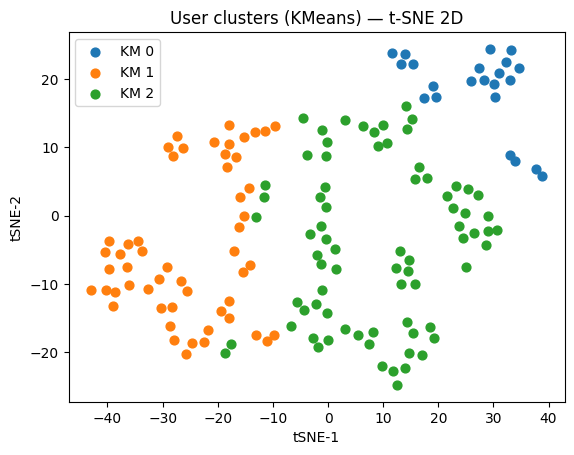

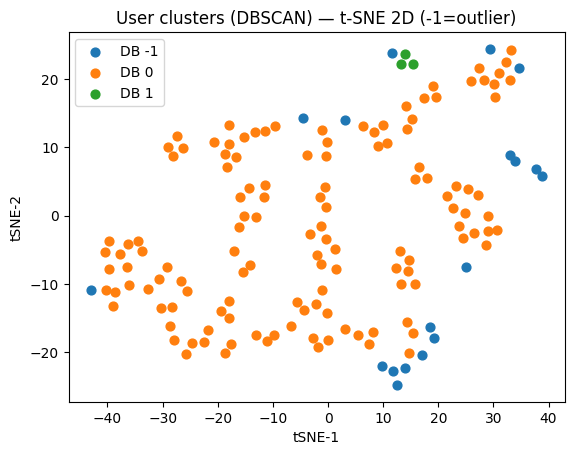


Clustered user features (head):
   user  avg_demand  std_demand  max_demand  peak_ratio  cluster_kmeans  \
0     0    3.564234    3.369259   17.033405    2.716461               2   
1     1    3.263516    3.113189   22.369490    2.945467               2   
2     2    3.780441    3.604659   17.892729    3.725505               2   
3     3    4.526805    4.417244   26.931578    3.273389               0   
4     4    3.049880    2.890512   17.402985    3.291793               2   

   cluster_dbscan  
0              -1  
1               0  
2              -1  
3               0  
4               0  

KMeans sizes:
 cluster_kmeans
2    75
1    53
0    22
Name: count, dtype: int64

DBSCAN labels (-1=outliers):
 cluster_dbscan
 0    129
-1     18
 1      3
Name: count, dtype: int64


In [20]:
# Minimal imports here (others already imported earlier in the notebook)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def make_user_features(df: pd.DataFrame, rush_col: str = "rush") -> pd.DataFrame:
    """Aggregate per-user features for clustering."""
    feats = []
    for u, sub in df.groupby("user"):
        avg = sub["demand"].mean()
        std = sub["demand"].std()
        maxd = sub["demand"].max()
        rush_mask = (sub[rush_col] == 1) if rush_col in sub.columns else pd.Series(False, index=sub.index)
        rush_avg = sub.loc[rush_mask, "demand"].mean() if rush_mask.any() else 0.0
        off_avg  = sub.loc[~rush_mask, "demand"].mean() if (~rush_mask).any() else 0.0
        peak_ratio = (rush_avg / off_avg) if off_avg > 0 else rush_avg
        feats.append({
            "user": u,
            "avg_demand": float(avg),
            "std_demand": float(0.0 if np.isnan(std) else std),
            "max_demand": float(maxd),
            "peak_ratio": float(peak_ratio),
        })
    return pd.DataFrame(feats)

def cluster_users_and_plot(
    n_users=60, days=3, interval_min=30,
    n_clusters=3, eps=0.7, min_samples=3, random_state=0,
    base_rate=1.0, peak_scale=6.0, peak_hours=[(7,9),(18,22)],
    lognorm_mu=0.0, lognorm_sigma=0.45,
    user_scale_mu=1.0, user_scale_sigma=0.25,
    max_rows=80_000
):
    """
    Generate dataset via existing `generate_energy_dataset(...)`, build features,
    cluster with KMeans & DBSCAN, and visualize with PCA and t-SNE.
    """
    # 1) synth data (reuse earlier generator name without "_light")
    df = generate_energy_dataset(
        num_users=n_users, days=days, interval_min=interval_min,
        base_rate=base_rate, peak_scale=peak_scale, peak_hours=peak_hours,
        lognorm_mu=lognorm_mu, lognorm_sigma=lognorm_sigma,
        user_scale_mu=user_scale_mu, user_scale_sigma=user_scale_sigma,
        seed=42, n_lags=0, rolling_window_intervals=1, horizon_intervals=0,
        max_rows=max_rows
    )
    # ensure required columns exist for clustering path
    # (generator already returns 'user','t','demand' and 'rush')
    dfu = make_user_features(df)

    # 2) scale features
    X = dfu.drop(columns=["user"]).values
    Xs = StandardScaler().fit_transform(X)

    # 3) clustering
    km = KMeans(n_clusters=n_clusters, random_state=random_state)
    labels_km = km.fit_predict(Xs)
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels_db = db.fit_predict(Xs)

    # 4) dimensionality reduction
    Xp = PCA(n_components=2, random_state=random_state).fit_transform(Xs)
    Xt = TSNE(n_components=2, perplexity=10, learning_rate="auto", init="pca",
              random_state=random_state).fit_transform(Xs)

    # 5) plots (one chart per figure)
    plt.figure()
    for lab in np.unique(labels_km):
        plt.scatter(Xt[labels_km==lab,0], Xt[labels_km==lab,1], label=f"KM {lab}", s=40)
    plt.title("User clusters (KMeans) — t-SNE 2D")
    plt.xlabel("tSNE-1"); plt.ylabel("tSNE-2"); plt.legend()
    plt.show()

    plt.figure()
    for lab in np.unique(labels_db):
        plt.scatter(Xt[labels_db==lab,0], Xt[labels_db==lab,1], label=f"DB {lab}", s=40)
    plt.title("User clusters (DBSCAN) — t-SNE 2D (-1=outlier)")
    plt.xlabel("tSNE-1"); plt.ylabel("tSNE-2"); plt.legend()
    plt.show()

    # 6) return labeled table
    dfu = dfu.copy()
    dfu["cluster_kmeans"] = labels_km
    dfu["cluster_dbscan"] = labels_db
    return dfu, Xp, Xt, labels_km, labels_db

# Demo
dfu, Xp, Xt, labels_km, labels_db = cluster_users_and_plot(
    n_users=150, days=5, interval_min=30, n_clusters=3, eps=0.7, min_samples=3, random_state=0
)
print("\nClustered user features (head):")
print(dfu.head())
print("\nKMeans sizes:\n", dfu["cluster_kmeans"].value_counts())
print("\nDBSCAN labels (-1=outliers):\n", dfu["cluster_dbscan"].value_counts())


# RL core classes: `SmartGridEnv` and `QLearner`
Slim, notebook-friendly versions that match the training/eval/randomization helpers.


In [21]:
import math, random
import numpy as np
from collections import deque, defaultdict
from typing import List, Optional, Tuple

def _gaussian_bump(minute: int, center_min: int, width_min: float) -> float:
    d = minute - center_min
    return math.exp(-(d*d)/(2*width_min*width_min))

def rush_intensity(minute_of_day: int,
                   centers: Tuple[int,int]=(8*60, 20*60),
                   width: float = 90.0,
                   base: float = 0.004,
                   peak_scale: float = 10.0) -> float:
    bump = sum(_gaussian_bump(minute_of_day, c, width) for c in centers)
    return base * (1.0 + peak_scale * bump)


In [25]:
class SmartGridEnv:
    """
    Learn u_H (share to Sensitive) to reduce: Sensitive blocking, Tolerant waiting, and Fossil usage.
    - Two queues: Sensitive (QH) & Tolerant (QL)
    - Action space: u_H ∈ {0, .25, .5, .75, 1.0}
    - Energy order: safe → battery → fossil; battery charges from leftover safe.
    - Outages via 'outage_mask' (True=all supplies zeroed that minute).
    - Arrivals: time-varying Poisson with rush peaks; can be patched per-episode.
    """
    def __init__(
        self,
        minutes_per_day: int = 1440,
        days: int = 5,
        battery_capacity: float = 3000.0,
        fossil_capacity_fn = lambda t: 120.0,  # per minute
        safe_peak: float = 350.0,
        block_window: int = 3,
        seed: int = 123,
        outage_mask: Optional[List[bool]] = None,
    ):
        self.waitL_sum = 0.0
        self.waitL_cnt = 0
        self.waitL_list = []   # optional: for p95 (can comment out if memory is tight)
        self.M = minutes_per_day
        self.T = days * self.M
        self.block_window = int(block_window)

        self.rng_np = np.random.RandomState(seed)
        self.rng_py = random.Random(seed)

        self.batt_cap = float(battery_capacity)
        self.batt = 0.0
        self.t = 0
        self.safe_peak = float(safe_peak)
        self.fossil_fn_raw = fossil_capacity_fn
        self.outage_mask = outage_mask if outage_mask is not None else [False]*self.T

        self.QH = deque()  # elements: [remaining_energy, arrival_t]
        self.QL = deque()

        self.q_bins = [0, 1, 4, 8, 16]
        self.b_bins = [0.0, 0.25, 0.5, 0.75, 1.01]
        self.rush_hours = [(7,9), (18,22)]

        self.actions = [0.0, 0.25, 0.5, 0.75, 1.0]

        # episode logs
        self.total_blocked_H = 0
        self.total_waitL = 0.0
        self.total_fossil = 0.0
        self.mix_safe = 0.0
        self.mix_batt = 0.0
        self.mix_foss = 0.0
        self.served_L = 0
        self.arrived_L = 0

    # --- supplies & arrivals ---

    def safe_supply(self, t: int) -> float:
        minute = t % self.M
        s = max(0.0, self.safe_peak * math.sin(math.pi * (minute / self.M)))
        return 0.0 if self.outage_mask[t] else s

    def fossil_capacity(self, t: int) -> float:
        return 0.0 if self.outage_mask[t] else float(self.fossil_fn_raw(t))

    def arrivals(self, t: int):
        """Default (can be overridden by domain randomization binder)."""
        m = t % self.M
        lam = rush_intensity(m, base=0.010, peak_scale=14.0)
        aH = int(self.rng_np.poisson(0.30 * lam))
        aL = int(self.rng_np.poisson(0.70 * lam))
        H = [float(self.rng_np.lognormal(mean=1.2, sigma=0.6)) for _ in range(aH)]
        L = [float(self.rng_np.lognormal(mean=1.4, sigma=0.6)) for _ in range(aL)]
        return H, L

    # --- observation helpers ---

    def _rush_flag(self, t: int) -> int:
        hour = (t % self.M) // 60
        return 1 if any(s <= hour < e for (s, e) in self.rush_hours) else 0

    def _supply_bucket(self, supply: float) -> int:
        if supply < 150: return 0
        if supply < 450: return 1
        return 2

    @staticmethod
    def _bucket(x: float, bins: List[float]) -> int:
        for i, b in enumerate(bins):
            if x < b: return i
        return len(bins)

    def _observe(self):
        t_obs = self.t if self.t < self.T else self.T - 1
        qh_b = self._bucket(len(self.QH), self.q_bins)
        ql_b = self._bucket(len(self.QL), self.q_bins)
        b_frac = self.batt / self.batt_cap if self.batt_cap > 0 else 0.0
        b_b = self._bucket(b_frac, self.b_bins)
        rush = self._rush_flag(t_obs)
        s_b = self._supply_bucket(self.safe_supply(t_obs) + self.fossil_capacity(t_obs))
        return (qh_b, ql_b, b_b, s_b, rush)

    # --- core env API ---

    def reset(self):
      self.batt = 0.0
      self.t = 0
      self.QH.clear(); self.QL.clear()
      self.total_blocked_H = 0
      self.total_waitL = 0.0
      self.total_fossil = 0.0
      self.mix_safe = self.mix_batt = self.mix_foss = 0.0
      self.served_L = 0; self.arrived_L = 0
      # NEW:
      self.waitL_sum = 0.0
      self.waitL_cnt = 0
      self.waitL_list = []
      return self._observe()

    # --- Replace your step() with this version (only diffs: queue item shape and wait tracking)
    def step(self, action_index: int):
      t = self.t
      u_H = self.actions[action_index]

      # (1) arrivals → include started flag False
      H_new, L_new = self.arrivals(t)
      for d in H_new: self.QH.append([d, t, False])   # [need, arr_t, started?]
      for d in L_new: self.QL.append([d, t, False])
      self.arrived_L += len(L_new)

      # (2) supplies
      safe = self.safe_supply(t)
      foss = self.fossil_capacity(t)
      batt = self.batt
      total = safe + batt + foss
      quota_H = u_H * total
      quota_L = (1.0 - u_H) * total
      used_safe = used_batt = used_foss = 0.0

      # local helper: serve from a queue under a quota; return updated resources and counts
      def serve(Q, quota, safe, batt, foss, used_safe, used_batt, used_foss):
          served_jobs = 0; i = 0; served_idx = []
          while i < len(Q) and quota > 1e-9:
              need, arr, started = Q[i]

              # — take from safe
              x = min(safe, min(need, quota)); safe -= x; need -= x; quota -= x
              if x > 0 and not started:
                  started = True
                  w = t - arr
                  self.waitL_sum += w; self.waitL_cnt += 1; self.waitL_list.append(w)
              used_safe += x

              # — take from battery
              if need > 1e-9 and quota > 1e-9:
                  x = min(batt, min(need, quota)); batt -= x; need -= x; quota -= x
                  if x > 0 and not started:
                      started = True
                      w = t - arr
                      self.waitL_sum += w; self.waitL_cnt += 1; self.waitL_list.append(w)
                  used_batt += x

              # — take from fossil
              if need > 1e-9 and quota > 1e-9:
                  x = min(foss, min(need, quota)); foss -= x; need -= x; quota -= x
                  if x > 0 and not started:
                      started = True
                      w = t - arr
                      self.waitL_sum += w; self.waitL_cnt += 1; self.waitL_list.append(w)
                  used_foss += x

              if need <= 1e-9:
                  served_idx.append(i); served_jobs += 1
              else:
                  Q[i][0] = need
                  Q[i][2] = started
              i += 1

          for k, idx in enumerate(served_idx):
              Q.remove(Q[idx - k])

          return served_jobs, safe, batt, foss, used_safe, used_batt, used_foss

      # (3) allocate → H then L  ←— call serve HERE
      served_H, safe, batt, foss, used_safe, used_batt, used_foss = serve(
          self.QH, quota_H, safe, batt, foss, used_safe, used_batt, used_foss
      )
      served_L, safe, batt, foss, used_safe, used_batt, used_foss = serve(
          self.QL, quota_L, safe, batt, foss, used_safe, used_batt, used_foss
      )
      self.served_L += served_L

      # (4) charge battery with leftover safe
      if safe > 1e-9:
          charge = min(self.batt_cap - batt, safe)
          batt += charge; safe -= charge

      # (5) block H if head exceeds window
      blocked = 0
      while self.QH and (t - self.QH[0][1]) >= self.block_window:
          self.QH.popleft(); blocked += 1

      waitL = len(self.QL)
      self.total_fossil += used_foss
      self.total_blocked_H += blocked
      self.total_waitL += waitL
      self.mix_safe += used_safe; self.mix_batt += used_batt; self.mix_foss += used_foss

      # (6) reward (negative cost)
      C_block, C_waitH, C_waitL, C_foss = 200.0, 0.20, 0.05, 0.02
      cost = C_block*blocked + C_waitH*len(self.QH) + C_waitL*waitL + C_foss*used_foss
      reward = -cost

      self.batt = batt
      self.t += 1
      done = (self.t >= self.T)
      return self._observe(), reward, done, {
          "blocked_H": blocked, "waitH": len(self.QH), "waitL": waitL,
          "used_safe": used_safe, "used_batt": used_batt, "used_fossil": used_foss
      }


In [26]:
class QLearner:
    """
    Tabular Q-learning with optimistic init and slow ε decay.
    Compatible with SmartGridEnv action space (len(env.actions)).
    """
    def __init__(self, n_actions: int, alpha=0.1, gamma=0.98,
                 eps_start=0.25, eps_end=0.05, eps_decay=0.9985):
        self.nA = n_actions
        self.Q = defaultdict(lambda: np.ones(self.nA, dtype=np.float32) * 0.5)
        self.visits = defaultdict(int)
        self.alpha = alpha
        self.gamma = gamma
        self.eps = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay

    def act(self, s):
        if random.random() < self.eps:
            return random.randrange(self.nA)
        q = self.Q[s]; maxq = np.max(q)
        ties = np.flatnonzero(q >= maxq - 1e-12)
        return int(np.random.choice(ties))

    def update(self, s, a, r, s2):
        self.visits[s] += 1
        qsa = self.Q[s][a]
        target = r + self.gamma * np.max(self.Q[s2])
        self.Q[s][a] = qsa + self.alpha * (target - qsa)

    def decay_eps(self):
        self.eps = max(self.eps_end, self.eps * self.eps_decay)


# RL: training with domain randomization (forces occasional fossil usage)

Per episode we randomize:
- **Green/battery scarcity:** lower `safe_peak`, smaller `battery_capacity`
- **Fossil availability:** moderate and penalized
- **Arrivals:** higher `base_rate`, higher `peak_scale`, Sensitive share ≈ 40%
- **Outages:** daily, probability `p=0.35`, duration 30–90 min (random hour)

We *patch* `env.arrivals` on the fly (no change to your `SmartGridEnv` class).


In [27]:
# --- Episode-level randomizers & binders ---

import types, random, math, numpy as np

def _bind_custom_arrivals(env,
                          base_rate: float,
                          peak_scale: float,
                          h_share: float = 0.40,
                          width_min: float = 90.0,
                          H_lognorm=(1.25, 0.60),
                          L_lognorm=(1.55, 0.65)):
    """
    Replace env.arrivals(t) with a stronger, time-varying Poisson generator.
    - base_rate: baseline arrivals/min
    - peak_scale: rush amplification
    - h_share: fraction of Sensitive arrivals
    """
    def _gauss(minute, center, width):
        d = minute - center
        return math.exp(-(d*d)/(2*width*width))

    centers = (8*60, 20*60)

    def arrivals(self, t):
        m = t % self.M
        bump = _gauss(m, centers[0], width_min) + _gauss(m, centers[1], width_min)
        lam = base_rate * (1.0 + peak_scale * bump)   # per minute
        lam_H = max(0.0, h_share) * lam
        lam_L = max(0.0, 1.0 - h_share) * lam
        aH = int(self.rng_np.poisson(lam_H))
        aL = int(self.rng_np.poisson(lam_L))
        H_mu, H_sig = H_lognorm
        L_mu, L_sig = L_lognorm
        H = [float(self.rng_np.lognormal(mean=H_mu, sigma=H_sig)) for _ in range(aH)]
        L = [float(self.rng_np.lognormal(mean=L_mu, sigma=L_sig)) for _ in range(aL)]
        return H, L

    env.arrivals = types.MethodType(arrivals, env)


def _maybe_daily_outage_mask(days, minutes_per_day, p=0.35, dur_min_rng=(30, 90), seed=0):
    """
    With probability p per day, add one outage window:
    - start hour uniform in {0..23}
    - duration uniform in dur_min_rng
    """
    rng = random.Random(seed)
    T = days * minutes_per_day
    mask = [False]*T
    for d in range(days):
        if rng.random() < p:
            start_h = rng.randrange(0, 24)
            dur = rng.randrange(dur_min_rng[0], dur_min_rng[1]+1)
            start = d*minutes_per_day + start_h*60
            for m in range(dur):
                i = start + m
                if i < (d+1)*minutes_per_day:
                    mask[i] = True
    return mask


def _retune_env_for_episode(env,
                            ep_idx: int,
                            days: int,
                            minutes_per_day: int = 1440,
                            seed: int = 0):
    """
    Domain randomization per episode:
    - safe_peak ~ U[80, 140]
    - battery_capacity ~ U[100, 350]
    - fossil cap const ~ U[120, 240]
    - arrivals: base ~ U[0.012, 0.022], peak_scale ~ U[12, 22], h_share ~ U[0.35, 0.50]
    - outage per day with p=0.35, duration 30–90 min
    - block_window randomly {2,3} (mostly 2)
    """
    rng = random.Random(seed + ep_idx)

    # capacities
    env.safe_peak = rng.uniform(80.0, 140.0)
    env.batt_cap  = rng.uniform(100.0, 350.0)

    foss_cap = rng.uniform(120.0, 240.0)
    env.fossil_fn_raw = (lambda cap: (lambda t: cap))(foss_cap)  # capture cap

    # outages
    env.outage_mask = _maybe_daily_outage_mask(
        days=days, minutes_per_day=minutes_per_day,
        p=0.35, dur_min_rng=(30, 90), seed=seed + 9999 + ep_idx
    )

    # arrivals
    base_rate  = rng.uniform(0.012, 0.022)
    peak_scale = rng.uniform(12.0, 22.0)
    h_share    = rng.uniform(0.35, 0.50)
    _bind_custom_arrivals(env, base_rate, peak_scale, h_share=h_share)

    # SLA
    env.block_window = 2 if rng.random() < 0.7 else 3


# Hardened training loop (uses the randomized curriculum)
Keeps your `SmartGridEnv` & `QLearner`. We re-tune the **same env** each episode.


In [28]:
def train_qlearning_harder(episodes=200, days=5, seed=2025):
    # Base env (values will be overwritten each episode by _retune_env_for_episode)
    env = SmartGridEnv(
        days=days,
        seed=seed,
        safe_peak=120.0,
        battery_capacity=250.0,
        fossil_capacity_fn=lambda t: 180.0,
        block_window=2,
        outage_mask=[False]*(days*1440)
    )
    agent = QLearner(n_actions=len(env.actions), alpha=0.1, gamma=0.98,
                     eps_start=0.25, eps_end=0.05, eps_decay=0.9985)

    returns = []
    for ep in range(episodes):
        _retune_env_for_episode(env, ep_idx=ep, days=days, seed=seed)  # domain randomization

        s = env.reset()
        G = 0.0
        while True:
            a = agent.act(s)
            s2, r, done, info = env.step(a)
            agent.update(s, a, r, s2)
            s = s2; G += r
            if done: break

        agent.decay_eps()
        returns.append(G)

        print(f"Ep {ep+1:03d} | G={G:8.2f} | eps={agent.eps:.3f} | "
              f"blkH={env.total_blocked_H:4d} | L_backlog={env.total_waitL:7.0f} | "
              f"mix: safe={env.mix_safe:7.0f}, batt={env.mix_batt:7.0f}, foss={env.mix_foss:7.0f}")

    return agent, returns


# Greedy evaluation (unchanged)
Greedy rollout + compact metrics based on env logs.


In [29]:
def evaluate_greedy(agent: QLearner, env: SmartGridEnv):
    def greedy_act(s):
        q = agent.Q[s]; maxq = np.max(q)
        ids = np.flatnonzero(q >= maxq - 1e-12)
        return int(np.random.choice(ids))

    s = env.reset(); G = 0.0
    while True:
        a = greedy_act(s)
        s2, r, done, info = env.step(a)
        s = s2; G += r
        if done: break

    green, batt, fossil = env.mix_safe, env.mix_batt, env.total_fossil
    totalE = green + batt + fossil if (green + batt + fossil) > 0 else 1.0
    return {
        "return": G,
        "blocked_H": env.total_blocked_H,
        "served_ratio_tolerant": (env.served_L / env.arrived_L) if env.arrived_L else 0.0,
        "avg_L_backlog_per_min": env.total_waitL / env.T,
        "fossil_used": fossil,
        "mix_green_pct": 100.0*green/totalE,
        "mix_batt_pct": 100.0*batt/totalE,
        "mix_fossil_pct": 100.0*fossil/totalE,
    }


# Scenario-aligned RL evaluation helpers
We’ll map your **three scenarios** to RL envs approximately.

To avoid the earlier outage helper mismatch, we include a **robust mask getter** that works whether the 3-arg or 4-arg `make_daily_outage_mask` is in scope.


In [30]:
def _get_outage_mask(days, minutes_per_day=1440, outage=False,
                     outage_duration_min=60, outage_seed=2025):
    if not outage:
        return [False]*(days*minutes_per_day)

    # try the 4-arg version first
    try:
        return make_daily_outage_mask(days, minutes_per_day, outage_duration_min, outage_seed)
    except TypeError:
        # fall back to 3-arg version (days, duration, seed)
        return make_daily_outage_mask(days, outage_duration_min, outage_seed)
    except NameError:
        # last resort: inline generator
        rng = random.Random(outage_seed)
        mask = [False]*(days*minutes_per_day)
        for d in range(days):
            start_hour = rng.randrange(0, 24)
            start = d*minutes_per_day + start_hour*60
            for m in range(outage_duration_min):
                i = start + m
                if i < (d+1)*minutes_per_day:
                    mask[i] = True
        return mask


def rl_env_from_scenario(days: int,
                         safe_peak_approx: float,
                         fossil_fn,
                         battery_capacity: float,
                         block_window: int,
                         outage: bool = False,
                         outage_duration_min: int = 60,
                         outage_seed: int = 2025,
                         minutes_per_day: int = 1440):
    mask = _get_outage_mask(days, minutes_per_day, outage, outage_duration_min, outage_seed)
    return SmartGridEnv(
        minutes_per_day=minutes_per_day,
        days=days,
        battery_capacity=battery_capacity,
        fossil_capacity_fn=fossil_fn,
        safe_peak=safe_peak_approx,
        block_window=block_window,
        outage_mask=mask
    )

def run_rl_scenarios(agent: QLearner):
    DAYS = 8

    # Scenario 1: No Outage — Barely Manageable (tighter than before)
    env1 = SmartGridEnv(
        days=DAYS,
        battery_capacity=350.0,        # smaller battery
        fossil_capacity_fn=lambda t: 110.0,
        safe_peak=260.0,               # lower green than before
        block_window=2,
        outage_mask=[False]*(DAYS*1440)
    )

    # Scenario 2: No Outage — Heavy/Infeasible
    env2 = SmartGridEnv(
        days=DAYS,
        battery_capacity=220.0,        # small battery
        fossil_capacity_fn=lambda t: 60.0,   # much lower fossil
        safe_peak=180.0,               # much lower green
        block_window=2,
        outage_mask=[False]*(DAYS*1440)
    )

    # Scenario 3: Daily outage — same as Scenario 1 + 1h outage/day
    def _mask(days, minutes_per_day=1440, outage_duration_min=60, seed=2025):
        rng = random.Random(seed)
        m = [False]*(days*minutes_per_day)
        for d in range(days):
            h = rng.randrange(0, 24)
            start = d*minutes_per_day + h*60
            for i in range(outage_duration_min):
                j = start + i
                if j < (d+1)*minutes_per_day:
                    m[j] = True
        return m

    env3 = SmartGridEnv(
        days=DAYS,
        battery_capacity=350.0,
        fossil_capacity_fn=lambda t: 110.0,
        safe_peak=260.0,
        block_window=2,
        outage_mask=_mask(DAYS, outage_duration_min=60, seed=2025)
    )

    for name, env in [
        ("RL — No Outage — Barely Manageable (tight)", env1),
        ("RL — No Outage — Heavy/Infeasible", env2),
        ("RL — Outage — Daily Random Hour (tight)", env3),
    ]:
        res = evaluate_greedy(agent, env)
        print(f"\n=== {name} ===")
        for k, v in res.items():
            print(f"{k:24s}: {v:.2f}" if isinstance(v, float) else f"{k:24s}: {v}")


# Example run
### Interpreting the Q-learning Training Logs

Each line in the training output corresponds to **one episode** (a full run of the environment).  
Example:


---

#### Fields

- **`Ep 005`**  
  The episode index (here: episode 5).

- **`G=  -10.97`**  
  The **total return** = sum of rewards across the episode.  
  Negative values mean costs outweigh rewards (due to blocking, waiting, or fossil usage).  
  Less negative → better performance.

- **`eps=0.248`**  
  The current **exploration rate ε**.  
  With probability ε, the agent takes a random action instead of the greedy one.  
  ε starts high and decays gradually each episode.

- **`blkH=   0`**  
  The number of **Sensitive (high-priority) jobs blocked**.  
  Blocking happens when a sensitive job waits longer than the `block_window`.  
  Even a single block is very costly.

- **`L_backlog=     75`**  
  The **cumulative tolerant backlog** across the episode.  
  It is the sum of tolerant queue lengths over time — a proxy for how much tolerant demand was left waiting.  
  Lower backlog is better, but not at the cost of blocking sensitive jobs.

- **`mix: safe=   5435, batt=     55, foss=      1`**  
  The **total energy supplied** by each source:  
  - **safe** = renewable/green energy used  
  - **batt** = battery energy drawn  
  - **foss** = fossil fuel energy consumed  

---

#### What this tells us

- In early episodes, **fossil = 0** most of the time → demand is met by safe + battery supply, so fossil is not needed.  
- **Blocking (blkH > 0)** causes a big drop in returns (large negative `G`).  
- As training progresses, occasional fossil usage appears, and returns move closer to zero (the agent is finding better trade-offs).  
- **Exploration rate (`eps`)** decreases episode by episode, meaning the agent relies more on its learned policy than on random actions.

---

**Summary of goals:**  
- Keep **`blkH = 0`** (no sensitive blocking).  
- Minimize **`L_backlog`** (tolerant wait times).  
- Maximize use of **safe** energy, use battery smartly, and minimize **fossil** reliance.


In [31]:
agent, returns = train_qlearning_harder(episodes=120, days=5, seed=2025)
run_rl_scenarios(agent)


Ep 001 | G=  -16.95 | eps=0.250 | blkH=   0 | L_backlog=    131 | mix: safe=   2327, batt=     44, foss=      0
Ep 002 | G=  -24.60 | eps=0.249 | blkH=   0 | L_backlog=    260 | mix: safe=   3929, batt=     64, foss=      0
Ep 003 | G=  -16.95 | eps=0.249 | blkH=   0 | L_backlog=    123 | mix: safe=   3615, batt=    126, foss=      0
Ep 004 | G=  -14.80 | eps=0.249 | blkH=   0 | L_backlog=    124 | mix: safe=   4576, batt=    120, foss=      0
Ep 005 | G= -211.47 | eps=0.248 | blkH=   1 | L_backlog=     73 | mix: safe=   5432, batt=     55, foss=      1
Ep 006 | G=   -7.30 | eps=0.248 | blkH=   0 | L_backlog=     50 | mix: safe=   3723, batt=     71, foss=      0
Ep 007 | G=   -4.40 | eps=0.247 | blkH=   0 | L_backlog=     28 | mix: safe=   4097, batt=     22, foss=      0
Ep 008 | G=   -5.05 | eps=0.247 | blkH=   0 | L_backlog=     25 | mix: safe=   3906, batt=     24, foss=      0
Ep 009 | G=   -5.93 | eps=0.247 | blkH=   0 | L_backlog=     40 | mix: safe=   3706, batt=     76, foss=